# 1. EDA

Este es el primer punto de entrada con nuestro dataset. Aquí exploraremos completamente los datos que se encuentran aquí. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 CARGA Y PRIMERA VISUALIZACIÓN


El dataset `insurance.csv` se cargará en el DataFrame `df`, que constituye nuestro punto de entrada para el análisis. Este conjunto de datos contiene **1,338 registros** y **7 columnas**, distribuidas en **4 variables numéricas** y **3 variables categóricas**.

### Variables del Dataset

| #   | Variable | Tipo | Descripción |
| --- | --- | --- | --- |
| 1   | **`age`** | Numérica | Edad del beneficiario principal (rango: 18-64 años) |
| 2   | **`sex`** | Categórica | Género del beneficiario: `female` / `male` |
| 3   | **`bmi`** | Numérica | Índice de Masa Corporal (IMC), indicador de obesidad (rango: 15-53) |
| 4   | **`children`** | Numérica | Número de hijos/dependientes cubiertos por el seguro (0-5) |
| 5   | **`smoker`** | Categórica | Hábito tabáquico: `yes` / `no` |
| 6   | **`region`** | Categórica | Región geográfica en Estados Unidos: `southwest`, `southeast`, `northwest`, `northeast` |
| 7   | **`charges`** | Numérica | **Variable Objetivo**: Costos médicos anuales facturados en dólares ($) |



In [2]:
df = pd.read_csv("../data/raw/insurance.csv")
df.sample(10) 

,age,sex,bmi,children,smoker,region,charges
320,34,male,25.27,1,no,northwest,4894.7533
149,19,male,28.40,1,no,southwest,1842.5190
510,56,male,32.11,1,no,northeast,11763.0009
1115,55,male,32.67,1,no,southeast,10807.4863
761,23,male,35.20,1,no,southwest,2416.9550
1239,25,female,42.13,1,no,southeast,3238.4357
852,46,female,35.53,0,yes,northeast,42111.6647
1290,38,female,19.95,2,no,northeast,7133.9025
587,34,female,30.21,1,yes,northwest,43943.8761
298,31,male,34.39,3,yes,northwest,38746.3551


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 1.2. Estadísticas descriptivas

Las variables numéricas no presentan, a primera vista, valores atípicos o inconsistentes. En particular, variables como `age`, `bmi`, `children` y `charges` no contienen valores negativos ni observaciones que resulten evidentemente absurdas, lo que sugiere una buena calidad inicial de los datos.

Por otro lado, las variables categóricas presentan un número reducido de valores únicos, lo cual es consistente con la naturaleza de este tipo de variables. Esto indica que cada una de ellas representa un conjunto de categorías bien definidas y no muestra inconsistencias aparentes en sus etiquetas.


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
df.describe(include = [object]).T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


## 1.3. Calidad de los datos (*Data Quality*)

No se encontraron valores nulos en el conjunto de datos. Esta observación fue confirmada tanto mediante la inspección de los datos como con el mapa de calor (*heatmap*), el cual muestra visualmente la ausencia de valores faltantes.

En cuanto a los registros duplicados, únicamente se identificó una observación repetida, correspondiente al índice `581`. Debido a que se trataba de un único registro duplicado, este fue eliminado sin afectar la representatividad del conjunto de datos. Posteriormente, se restableció el índice para mantener una numeración consecutiva y facilitar el análisis posterior.

Respecto a la distribución de las variables categóricas, en general presentan un reparto equilibrado entre sus categorías. La única excepción es la variable `smoker`, en la que existe un desbalance moderado: se registran **1063** personas no fumadoras frente a **274** fumadoras. Aunque esta diferencia es considerable, no representa un desbalance extremo que impida el desarrollo del análisis. En las demás variables categóricas, las frecuencias son relativamente similares entre sus categorías, por lo que no se observan desequilibrios significativos.


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: >

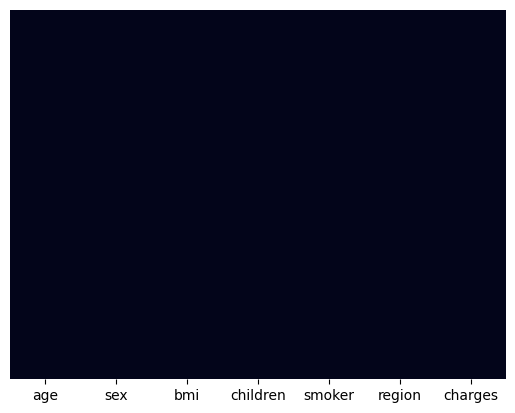

In [7]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df = df.drop_duplicates()

In [11]:
df.reset_index()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1332,1333,50,male,30.970,3,no,northwest,10600.54830
1333,1334,18,female,31.920,0,no,northeast,2205.98080
1334,1335,18,female,36.850,0,no,southeast,1629.83350
1335,1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
print(df['sex'].unique())        
print(df['smoker'].unique())    
print(df['region'].unique())     

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [13]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 1.4. ANÁLISIS DE VARIABLES NUMÉRICAS

In [14]:
df_numerico = df.select_dtypes(include=["number"])


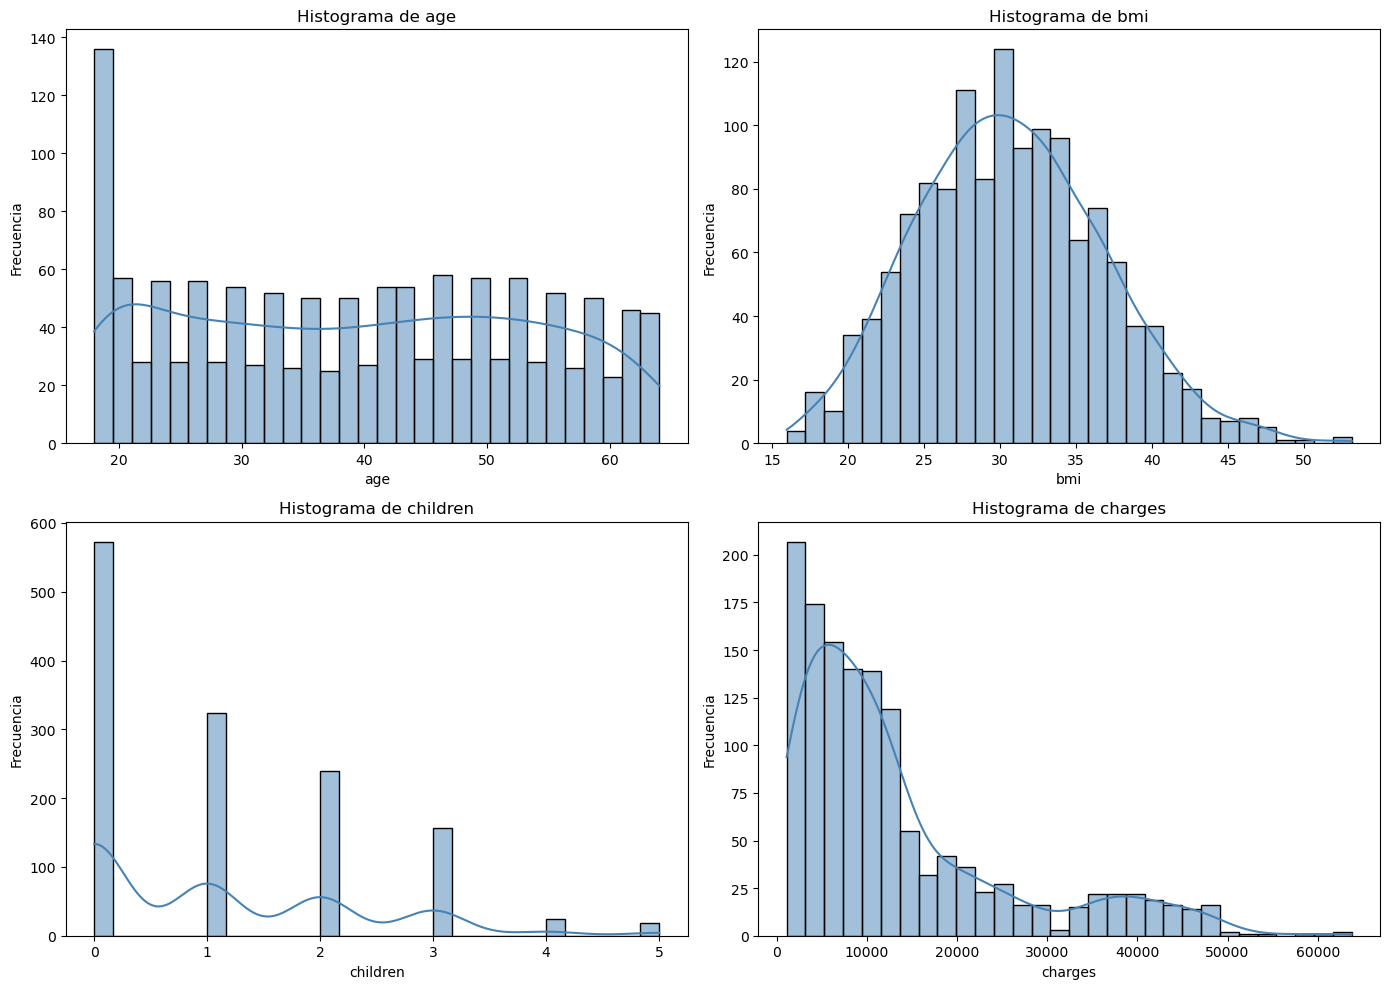

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, col in zip(axes.flatten(), df_numerico.columns):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color="steelblue",
        edgecolor="black",
        ax=ax
    )

    ax.set_title(f'Histograma de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

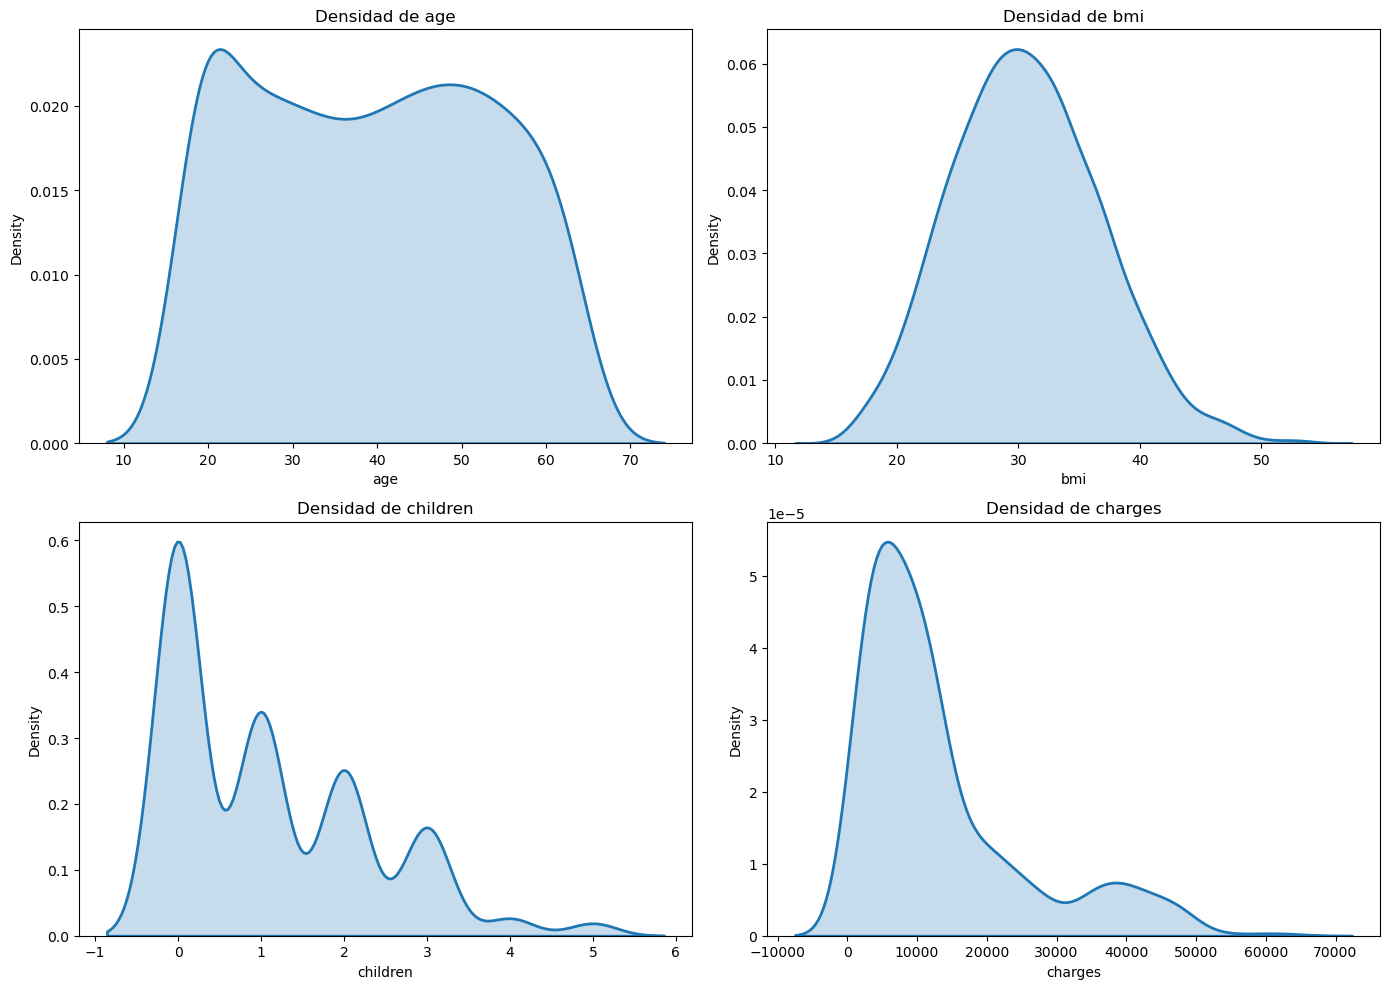

In [16]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, col in zip(axes.flatten(), df_numerico.columns):

    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        linewidth=2,
        ax=ax
    )

    ax.set_title(f'Densidad de {col}')

plt.tight_layout()
plt.show()

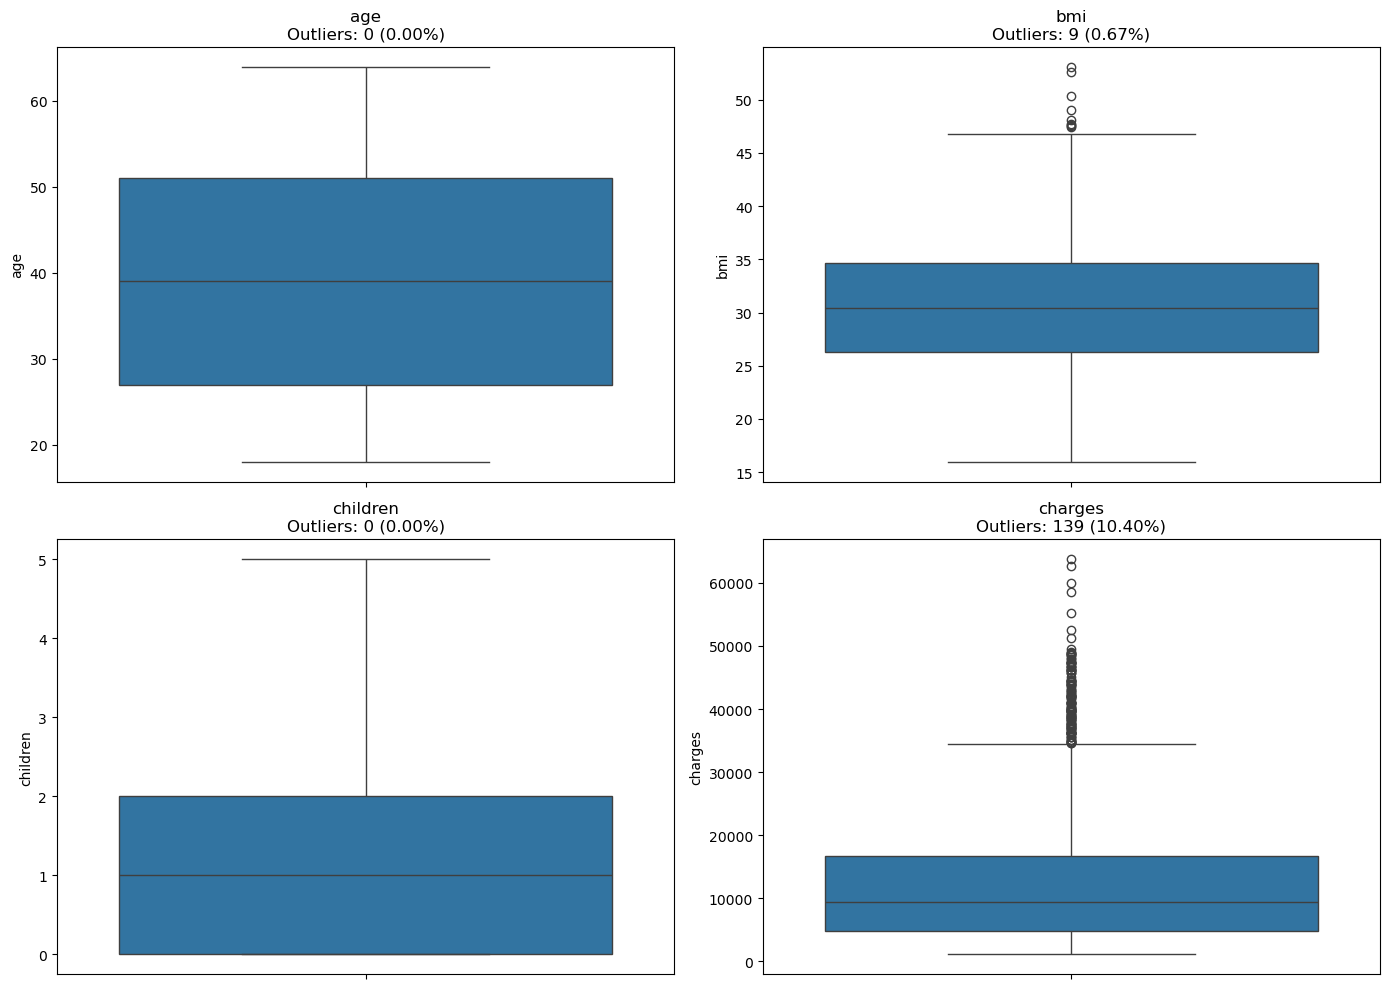

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), df_numerico.columns):

    # Cálculo del IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificación de outliers
    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    sns.boxplot(
        data=df,
        y=col,
        ax=ax
    )

    ax.set_title(
        f'{col}\nOutliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)'
    )

plt.tight_layout()
plt.show()

## 1.5. ANÁLISIS DE VARIABLES CATEGÓRICAS


In [18]:
df_categorico = df.select_dtypes(include=["object", "category", "bool"])

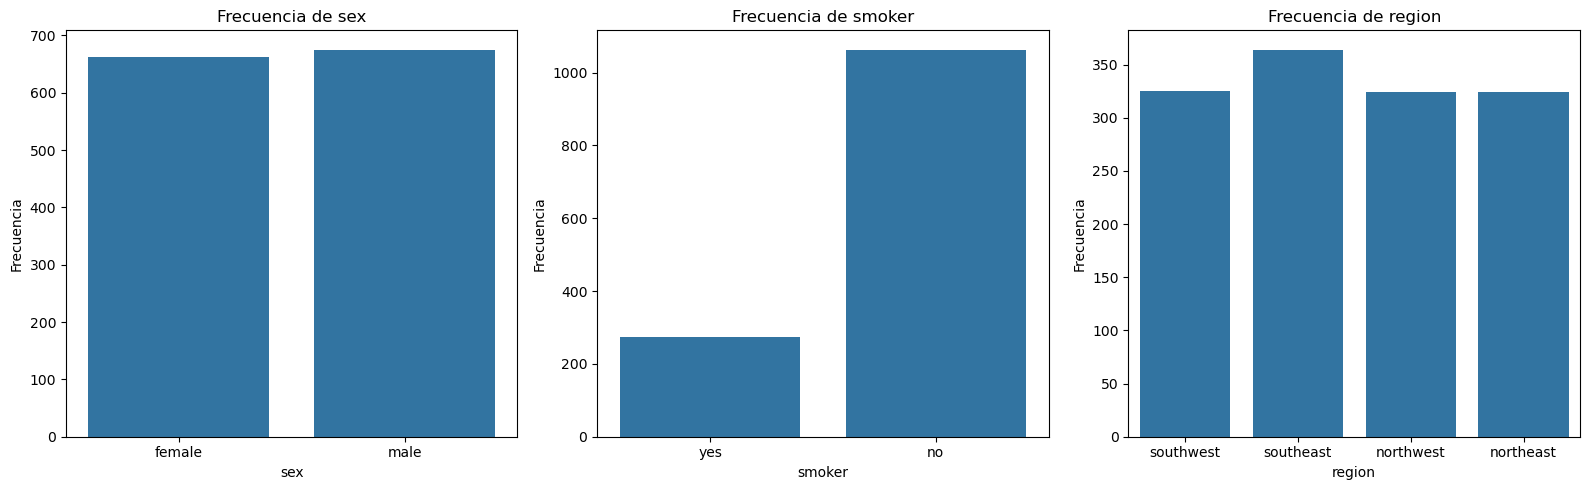

In [19]:
fig, axes = plt.subplots(1, len(df_categorico.columns), figsize=(16, 5))

if len(df_categorico.columns) == 1:
    axes = [axes]

for ax, col in zip(axes, df_categorico.columns):

    sns.countplot(
        data=df,
        x=col,
        ax=ax
    )

    ax.set_title(f'Frecuencia de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 1.6 RELACIONES ENTRE VARIABLES



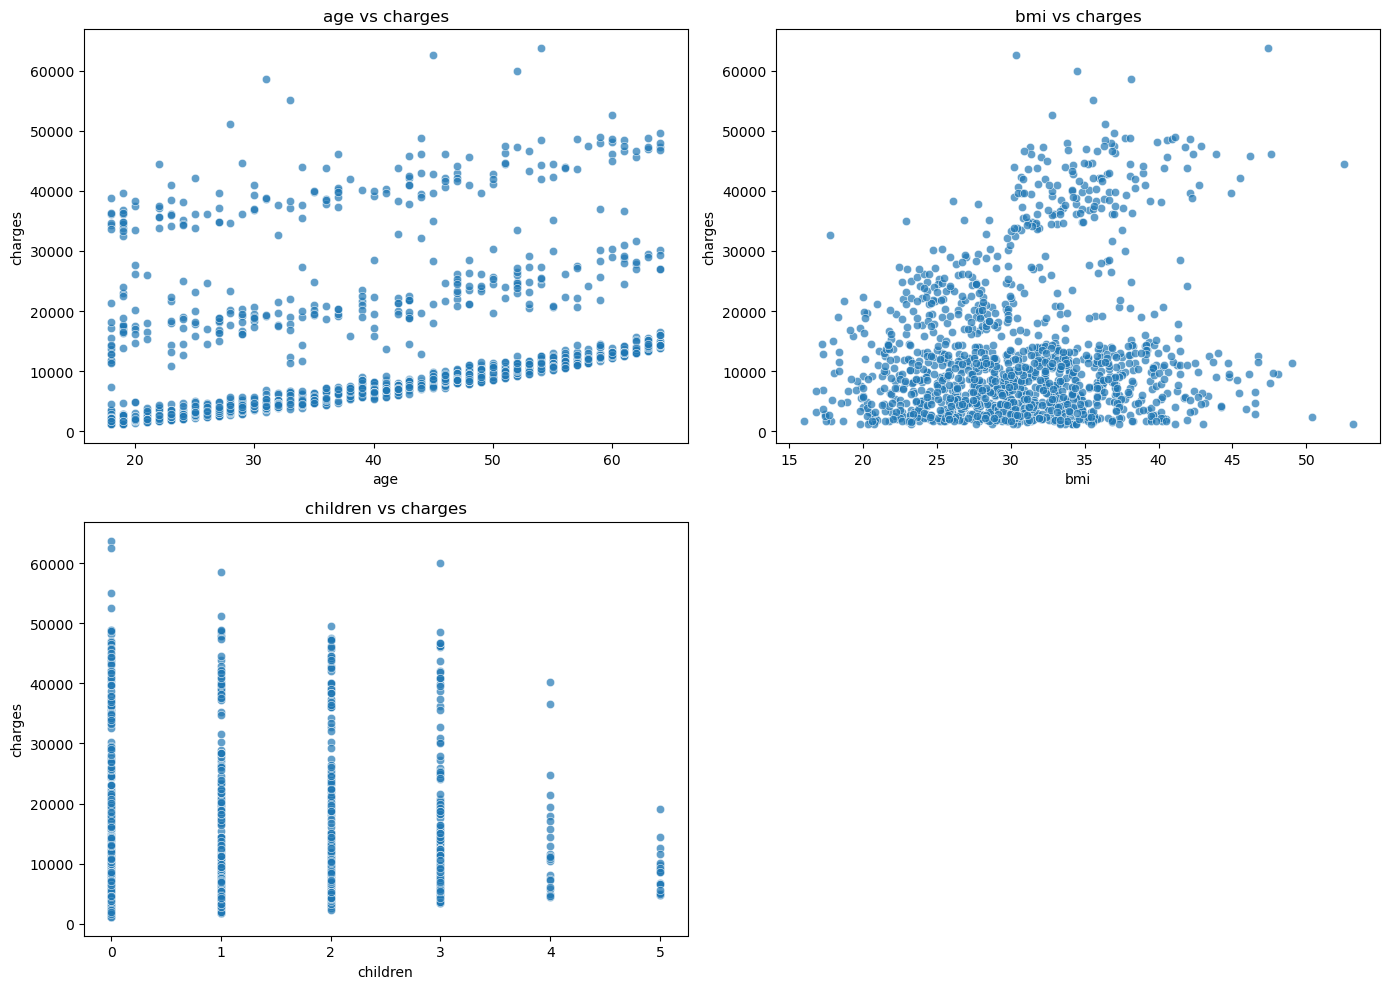

In [20]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

variables = [col for col in df_numerico.columns if col != "charges"]

for ax, col in zip(axes.flatten(), variables):

    sns.scatterplot(
        data=df,
        x=col,
        y="charges",
        alpha=0.7,
        ax=ax
    )

    ax.set_title(f'{col} vs charges')

# Elimina el último subplot vacío
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

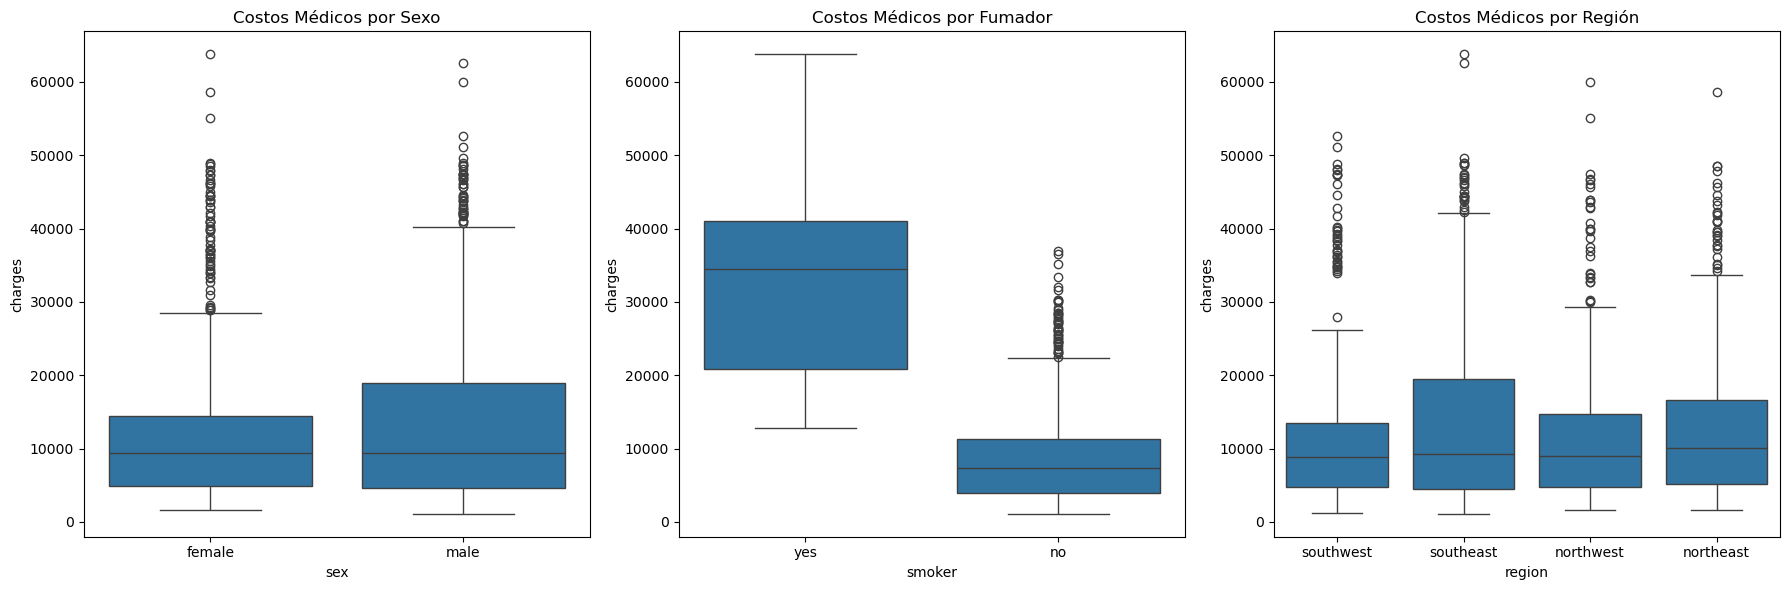

In [22]:
# Charges por categorías
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sex
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Costos Médicos por Sexo')

# Smoker (IMPORTANTE)
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1])
axes[1].set_title('Costos Médicos por Fumador')

# Region
sns.boxplot(data=df, x='region', y='charges', ax=axes[2])
axes[2].set_title('Costos Médicos por Región')

plt.tight_layout()
plt.show()

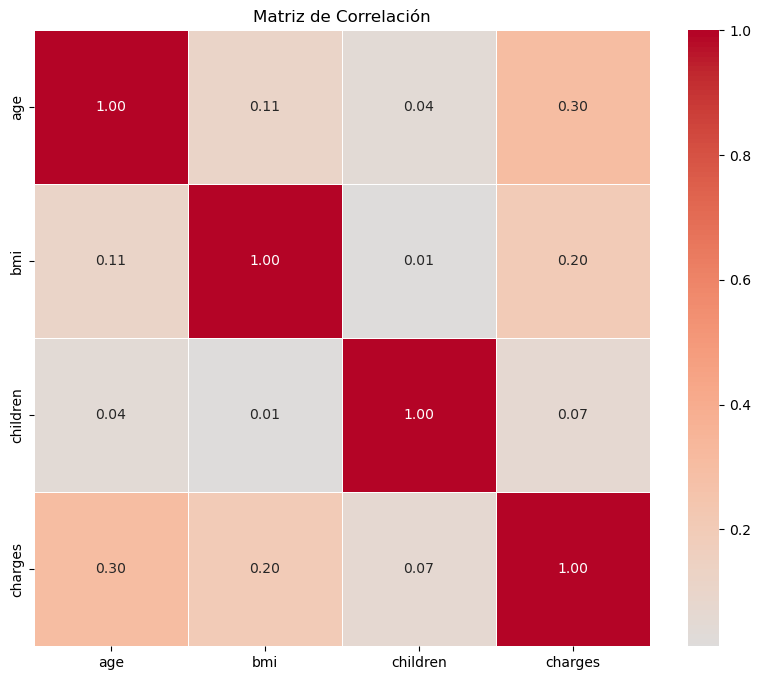

In [23]:
# Matriz de correlación (solo numéricas)
correlation_matrix = df[['age', 'bmi', 'children', 'charges']].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()